In [ ]:
import numpy as np
import pandas as pd
import sklearn.model_selection as ms
import sklearn.ensemble as en
import sklearn.metrics as met

campaign = pd.read_csv('https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/bank.csv')

In [ ]:
X = pd.get_dummies(campaign.drop(columns=["y"]), drop_first=True)
y = campaign["y"]

X_train, X_test, y_train, y_test = ms.train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

clf = en.RandomForestClassifier(
    n_estimators=600,          # Number of trees in the forest (more trees = usually better performance but slower)

    max_depth=15,              # Maximum depth of each tree (limits complexity to reduce overfitting)

    min_samples_leaf=10,       # Minimum samples required in a leaf node (higher = smoother trees, less overfitting)

    random_state=42,           # Makes results reproducible (same randomness every run)

    class_weight={"no": 1, "yes": 5},  # Penalizes mistakes on "yes" more heavily (helps catch more "yes" cases / raises recall)

    max_features="sqrt",       # Number of features each split can consider (sqrt is common; adds randomness, reduces overfitting)

    bootstrap=True,            # Uses bootstrapped samples (random sampling with replacement) for each tree (default RF behavior)

    n_jobs=-1                  # Uses all CPU cores to train faster
)


clf.fit(X_train, y_train)
pred = clf.predict(X_test)

print(met.classification_report(y_test, pred))
print(met.confusion_matrix(y_test, pred))


BASELINE MODEL RESULTS (default threshold = 0.50)
              precision    recall  f1-score   support

          no       0.95      0.91      0.93      9859
         yes       0.45      0.60      0.52      1262

    accuracy                           0.87     11121
   macro avg       0.70      0.75      0.72     11121
weighted avg       0.89      0.87      0.88     11121

[[8923  936]
 [ 499  763]]


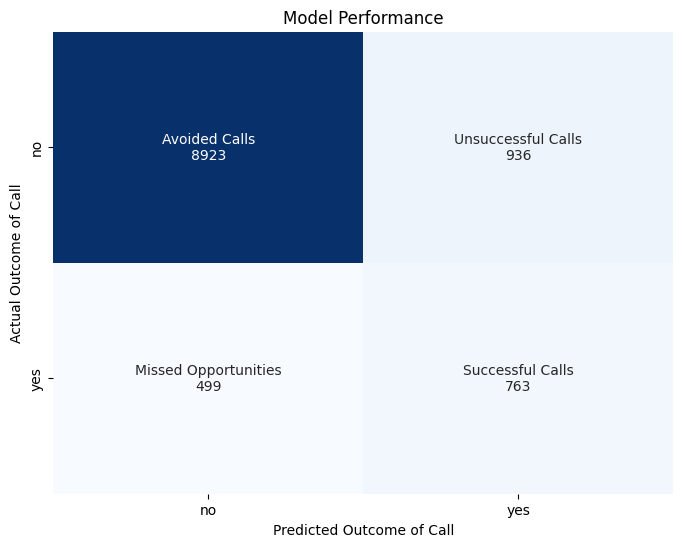

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np


def plot_business_confusion_matrix(y_true, y_pred, labels=['No', 'Yes']):
   cm = confusion_matrix(y_true, y_pred, labels=labels)


   group_names = ['Avoided Calls', 'Unsuccessful Calls',
                  'Missed Opportunities', 'Successful Calls']


   group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]


   labels_flat = [f"{v1}\n{v2}" for v1, v2 in zip(group_names, group_counts)]
   labels_reshaped = np.asarray(labels_flat).reshape(2,2)


   plt.figure(figsize=(8, 6))
   sns.heatmap(cm, annot=labels_reshaped, fmt='', cmap='Blues', cbar=False, xticklabels=labels, yticklabels=labels)
   plt.xlabel('Predicted Outcome of Call')
   plt.ylabel('Actual Outcome of Call')
   plt.title('Model Performance')
   plt.show()


plot_business_confusion_matrix(y_test, pred, labels=['no', 'yes'])

In [ ]:
final_pred_df = pd.read_csv('https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/bank_holdout_test.csv')
final_pred_df = pd.get_dummies(final_pred_df)

# This part ensures that the final_pred_df has the same colums as the training columns
train_cols = X_train.columns
final_pred_df = final_pred_df.reindex(columns=train_cols, fill_value=0)
final_pred = clf.predict(final_pred_df)
# Convert the NumPy Array to a pandas Array
final_pred = pd.DataFrame({
    'prediction': final_pred
})

# Map the 'yes' and 'no' to 1 and 0
final_pred['prediction'] = final_pred['prediction'].map({
    'yes': 1,
    'no': 0
})

# Save as a csv
final_pred.to_csv('predictions.csv', index=False)